In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
# Load Dataset

df = pd.read_csv("../data/Retail_Transaction_Dataset.csv")

print(df.shape)
df.head()

(100000, 10)


,CustomerID,ProductID,Quantity,Price,TransactionDate,PaymentMethod,StoreLocation,ProductCategory,DiscountApplied(%),TotalAmount
0,109318,C,7,80.079844,12/26/2025 12:32,Cash,"176 Andrew Cliffs\nBaileyfort, HI 93354",Books,18.677100,455.862764
1,993229,C,4,75.195229,08-05-2025 00:00,Cash,"11635 William Well Suite 809\nEast Kara, MT 19483",Home Decor,14.121365,258.306546
2,579675,A,8,31.528816,03-11-2026 18:51,Cash,"910 Mendez Ville Suite 909\nPort Lauraland, MO...",Books,15.943701,212.015651
3,799826,D,5,98.880218,10/27/2025 22:00,PayPal,"87522 Sharon Corners Suite 500\nLake Tammy, MO...",Books,6.686337,461.343769
4,121413,A,7,93.188512,12/22/2025 11:38,Cash,"0070 Michelle Island Suite 143\nHoland, VA 80142",Electronics,4.030096,626.030484


In [4]:
# Data Preprocessing

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"],format="mixed")

customer_df = (
    df.groupby("CustomerID")
    .agg(
        TotalSpent=("TotalAmount", "sum"),
        QuantityPurchased=("Quantity", "sum"),
        Frequency=("TransactionDate", "count"),
        AverageOrderValue=("TotalAmount", "mean"),
        AverageQuantityPerTransaction=("Quantity", "mean"),
        LastPurchase=("TransactionDate", "max")
    )
    .reset_index()
)

reference_date = df["TransactionDate"].max()

customer_df["Recency"] = (
    reference_date - customer_df["LastPurchase"]
).dt.days

customer_df.drop(columns=["LastPurchase"], inplace=True)

customer_df.head()

,CustomerID,TotalSpent,QuantityPurchased,Frequency,AverageOrderValue,AverageQuantityPerTransaction,Recency
0,14,256.232791,5,1,256.232791,5.0,265
1,42,502.656523,7,1,502.656523,7.0,344
2,49,21.399047,1,1,21.399047,1.0,327
3,59,249.492696,12,2,124.746348,6.0,27
4,65,548.006625,8,1,548.006625,8.0,314


In [5]:
# Feature Selection

features = [
    "TotalSpent",
    "QuantityPurchased",
    "Frequency",
    "AverageOrderValue",
    "AverageQuantityPerTransaction",
    "Recency"
]

X = customer_df[features]

X.head()

,TotalSpent,QuantityPurchased,Frequency,AverageOrderValue,AverageQuantityPerTransaction,Recency
0,256.232791,5,1,256.232791,5.0,265
1,502.656523,7,1,502.656523,7.0,344
2,21.399047,1,1,21.399047,1.0,327
3,249.492696,12,2,124.746348,6.0,27
4,548.006625,8,1,548.006625,8.0,314


In [6]:
# Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-2.32465103e-02, -9.07984049e-02, -2.22016222e-01,
         4.30070772e-02, -3.99244888e-03,  8.28624430e-01],
       [ 1.22692653e+00,  6.04894049e-01, -2.22016222e-01,
         1.39387382e+00,  7.80612340e-01,  1.58085310e+00],
       [-1.21462046e+00, -1.48218331e+00, -2.22016222e-01,
        -1.24432467e+00, -1.57320203e+00,  1.41898111e+00],
       [-5.74408038e-02,  2.34412518e+00,  4.19580500e+00,
        -6.77786579e-01,  3.88309946e-01, -1.43758345e+00],
       [ 1.45699964e+00,  9.52740276e-01, -2.22016222e-01,
         1.64247789e+00,  1.17291473e+00,  1.29519664e+00]])

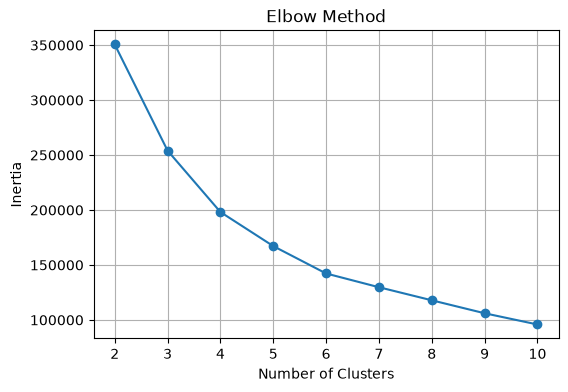

In [7]:
# Elbow Method

inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [8]:
# Improved KMeans Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df["CustomerGroup"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,CustomerID,TotalSpent,QuantityPurchased,Frequency,AverageOrderValue,AverageQuantityPerTransaction,Recency,CustomerGroup
0,14,256.232791,5,1,256.232791,5.0,265,0
1,42,502.656523,7,1,502.656523,7.0,344,2
2,49,21.399047,1,1,21.399047,1.0,327,0
3,59,249.492696,12,2,124.746348,6.0,27,1
4,65,548.006625,8,1,548.006625,8.0,314,2


In [9]:
# Model Evaluation

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

sil_score = silhouette_score(
    X_scaled,
    customer_df["CustomerGroup"]
)

ch_score = calinski_harabasz_score(
    X_scaled,
    customer_df["CustomerGroup"]
)

db_score = davies_bouldin_score(
    X_scaled,
    customer_df["CustomerGroup"]
)

print("="*60)
print("Customer Segmentation Evaluation")
print("="*60)

print(f"Silhouette Score          : {sil_score:.4f}")
print(f"Calinski-Harabasz Score   : {ch_score:.2f}")
print(f"Davies-Bouldin Index      : {db_score:.4f}")

Customer Segmentation Evaluation
Silhouette Score          : 0.3976
Calinski-Harabasz Score   : 59460.88
Davies-Bouldin Index      : 0.9238


In [10]:
# Cluster Analysis

cluster_summary = (
    customer_df
    .groupby("CustomerGroup")[features]
    .mean()
    .round(2)
)

cluster_size = (
    customer_df["CustomerGroup"]
    .value_counts()
    .sort_index()
)

print("="*60)
print("Cluster Summary")
print("="*60)
print(cluster_summary)

print("\n")
print("="*60)
print("Customers per Cluster")
print("="*60)
print(cluster_size)

Cluster Summary
               TotalSpent  QuantityPurchased  Frequency  AverageOrderValue  \
CustomerGroup                                                                
0                  125.91               3.09       1.00             125.91   
1                  503.23              10.15       2.04             247.16   
2                  395.85               7.33       1.00             395.85   

               AverageQuantityPerTransaction  Recency  
CustomerGroup                                          
0                                       3.09   180.56  
1                                       4.99   117.84  
2                                       7.33   181.63  


Customers per Cluster
CustomerGroup
0    49468
1     4621
2    41126
Name: count, dtype: int64


In [11]:
# Save Improved Customer Segmentation

customer_df.to_csv(
    "../data/improved_customer_segmentation.csv",
    index=False
)

print("=" * 60)
print("Improved Customer Segmentation Completed Successfully")
print("=" * 60)

print(f"Customers                 : {customer_df.shape[0]}")
print(f"Clusters                  : {customer_df['CustomerGroup'].nunique()}")
print(f"Silhouette Score          : {sil_score:.4f}")
print(f"Calinski-Harabasz Score   : {ch_score:.2f}")
print(f"Davies-Bouldin Index      : {db_score:.4f}")

print("\nFile Saved As:")
print("../data/improved_customer_segmentation.csv")

Improved Customer Segmentation Completed Successfully
Customers                 : 95215
Clusters                  : 3
Silhouette Score          : 0.3976
Calinski-Harabasz Score   : 59460.88
Davies-Bouldin Index      : 0.9238

File Saved As:
../data/improved_customer_segmentation.csv


In [12]:
import joblib

joblib.dump(
    kmeans,
    "../models/improved_customer_segmentation.pkl"
)

print("="*60)
print("Customer Segmentation Model Saved Successfully")
print("="*60)
print("Saved As:")
print("../models/improved_customer_segmentation.pkl")

Customer Segmentation Model Saved Successfully
Saved As:
../models/improved_customer_segmentation.pkl
